# ⚖️ Court Appeal Outcome Prediction
### ML Pipeline — Feature Engineering + Modeling
---

## 📦 Step 1: Install & Import Libraries

In [9]:
# Install required packages (run once)
# !pip install imbalanced-learn scikit-learn pandas numpy matplotlib seaborn
# !pip install "numpy<2" --upgrade
# !pip install --upgrade numexpr bottleneck
# !pip install --upgrade imbalanced-learn scikit-learn
# !pip install --upgrade pandas

In [10]:
import pandas as pd
import numpy as np
import pickle
import json
import warnings
import re
from datetime import datetime
warnings.filterwarnings('ignore')

# Sklearn - Feature Engineering
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Sklearn - Modeling
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_recall_fscore_support,
    f1_score
)

# Imbalanced learning
from imblearn.over_sampling import SMOTE

# Visualization
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Plot style
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print('✅ All libraries imported successfully!')
print(f'Run time: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')

✅ All libraries imported successfully!
Run time: 2026-03-09 10:23:45


---
## 📂 Step 2: Load Dataset

In [12]:
# Load your cleaned dataset
df = pd.read_csv('dataset_cleaned_v2.csv')

print(f'📊 Dataset Shape: {df.shape}')
print(f'📋 Columns ({len(df.columns)}):\n')
for col in df.columns:
    print(f'  • {col} — {df[col].dtype} | nulls: {df[col].isna().sum()}')

📊 Dataset Shape: (1251, 98)
📋 Columns (98):

  • Unnamed: 0 — int64 | nulls: 0
  • source_file_name — str | nulls: 0
  • court_of_appeal_case_no — str | nulls: 23
  • high_court_case_no — str | nulls: 69
  • high_court_location — str | nulls: 49
  • judgment_date_coa — str | nulls: 1
  • judgment_date_hc — str | nulls: 291
  • date_of_offence — str | nulls: 292
  • judges — str | nulls: 0
  • offence_sections — str | nulls: 114
  • offence_category — str | nulls: 0
  • location_of_offence — str | nulls: 457
  • language_of_criminal — str | nulls: 1007
  • brief_facts_summary — str | nulls: 0
  • evidence_type_primary — str | nulls: 67
  • evidence_type_secondary — str | nulls: 224
  • hc_offence_of_conviction_sections — str | nulls: 218
  • hc_sentence_type — str | nulls: 219
  • hc_fine_amount — float64 | nulls: 774
  • hc_compensation_amount — float64 | nulls: 1001
  • hc_judgment_summary — str | nulls: 48
  • grounds_of_appeal_raw_text_summary — str | nulls: 0
  • grounds_of_appeal_

In [13]:
# Preview the data
df.head(3)

,Unnamed: 0,source_file_name,court_of_appeal_case_no,high_court_case_no,high_court_location,judgment_date_coa,judgment_date_hc,date_of_offence,judges,offence_sections,...,conviction_clean,combined_outcome,coa_year,coa_month,appeal_duration_days,total_grounds_raised,medical_evidence_score,custody_score,offence_category_grouped,appeal_type_simplified
0,0,January_criminal_judgment_1120.pdf,CA 488/2017,HC/COLOMBO/6796/2013,Colombo,2022-01-28,2017-01-31,2011-05-02,"Sampath B. Abayakoon, J. | P. Kumararatnam, J.","Sections 54(A)(d) and 54(A)(b) of the Poisons,...",...,Convicted,Allowed_Convicted_Reduced,2022.0,1.0,1823.0,3,1.0,1.0,Drug_Related,Sentence_Only
1,3,January_criminal_judgment_1124.pdf,CA/HCC/0005/19,HC/4664/2009,Colombo,2022-01-27,NaN,1999-09-25,Sampath B Abayakoon J. | K. Priyantha Fernando...,Section 296 read with Sections 102 and 113A of...,...,Acquitted,Allowed_Acquitted,2022.0,1.0,NaN,2,1.0,1.0,Murder_Related,Both
2,4,January_criminal_judgment_1128.pdf,CA/PHC/APN/65/2021,Bail Application No: 99/2020,Matara,2022-01-25,2021-03-10,2020-05-26,Menaka Wijesundera J. | Neil Iddawala J.,Section 83(1) read with sections 54A and 54B o...,...,Remanded,Other,2022.0,1.0,321.0,1,1.0,1.0,Drug_Related,Revision


🎯 Target Variable Distribution:
outcome_clean
Appeal_Dismissed    588
Appeal_Allowed      505
Partly_Allowed      158
Name: count, dtype: int64


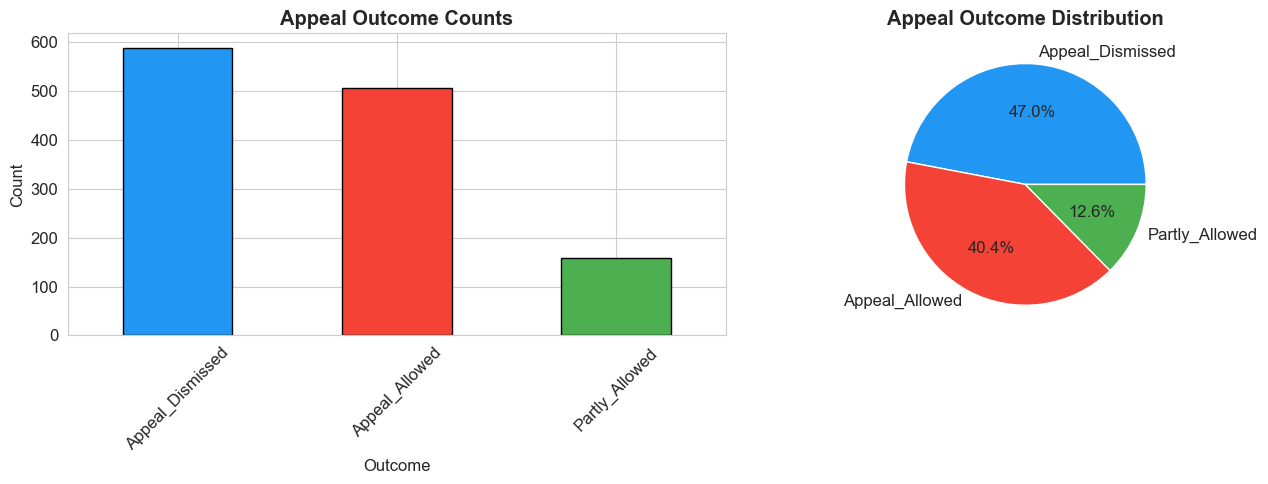

In [14]:
# Target distribution
print('🎯 Target Variable Distribution:')
outcome_counts = df['outcome_clean'].value_counts()
print(outcome_counts)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
outcome_counts.plot(kind='bar', ax=axes[0], color=['#2196F3', '#F44336', '#4CAF50', '#FF9800'], edgecolor='black')
axes[0].set_title('Appeal Outcome Counts', fontweight='bold')
axes[0].set_xlabel('Outcome')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Pie chart
axes[1].pie(outcome_counts.values, labels=outcome_counts.index,
            autopct='%1.1f%%', colors=['#2196F3', '#F44336', '#4CAF50', '#FF9800'])
axes[1].set_title('Appeal Outcome Distribution', fontweight='bold')

plt.tight_layout()
plt.show()

---
## 🔤 Step 3: TF-IDF Text Vectorization

In [15]:
# Combine text columns
text_columns = ['brief_facts_summary', 'grounds_of_appeal_raw_text_summary', 'court_of_appeal_analysis_summary']

# Check which text columns exist
available_text_cols = [c for c in text_columns if c in df.columns]
print(f'Text columns available: {available_text_cols}')

df['combined_text'] = df[available_text_cols].fillna('').agg(' '.join, axis=1)

# Filter empty texts
df = df[df['combined_text'].str.len() > 10].copy()
print(f'Records after filtering: {len(df)}')

# Sample text preview
print(f'\n📝 Sample combined text (first 300 chars):')
print(df['combined_text'].iloc[0][:300])

Text columns available: ['brief_facts_summary', 'grounds_of_appeal_raw_text_summary', 'court_of_appeal_analysis_summary']
Records after filtering: 1251

📝 Sample combined text (first 300 chars):
The respondent, a repeat offender for heroin-related offences, was arrested during a police raid by officers of the Welikada Police Station around 4.25 p.m. on 02 May 2011 in front of the Buddha Statue at Maligawa Road, Ethul Kotte. He was found in possession of a bag hidden in his trouser pocket co


In [16]:
# Fit TF-IDF
tfidf_vectorizer = TfidfVectorizer(
    max_features=1000,
    min_df=1,
    max_df=0.95,
    ngram_range=(1, 2),
    stop_words='english',
    lowercase=True,
    strip_accents='ascii'
)

tfidf_matrix = tfidf_vectorizer.fit_transform(df['combined_text'])
tfidf_features = tfidf_vectorizer.get_feature_names_out()

print(f'✅ TF-IDF Complete!')
print(f'   Matrix shape: {tfidf_matrix.shape}')
print(f'   Features created: {len(tfidf_features)}')
print(f'   Top 20 features: {list(tfidf_features[:20])}')

✅ TF-IDF Complete!
   Matrix shape: (1251, 1000)
   Features created: 1000
   Top 20 features: ['000', '01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19']


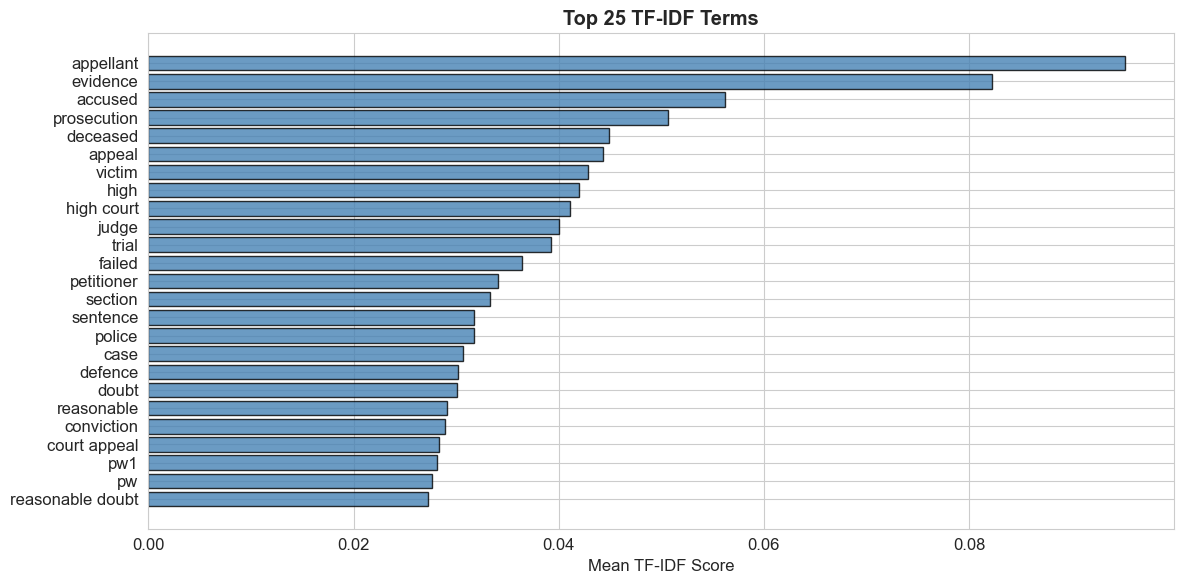

In [17]:
# Visualize top TF-IDF terms by score
tfidf_scores = np.asarray(tfidf_matrix.mean(axis=0)).flatten()
top_n = 25
top_indices = tfidf_scores.argsort()[-top_n:][::-1]
top_terms = [tfidf_features[i] for i in top_indices]
top_scores = tfidf_scores[top_indices]

plt.figure(figsize=(12, 6))
plt.barh(top_terms[::-1], top_scores[::-1], color='steelblue', edgecolor='black', alpha=0.8)
plt.xlabel('Mean TF-IDF Score')
plt.title(f'Top {top_n} TF-IDF Terms', fontweight='bold')
plt.tight_layout()
plt.show()

---
## ⚖️ Step 4: Legal Feature Extraction

In [18]:
def extract_all_legal_features(df):
    """Extract comprehensive legal features from case text"""
    features = pd.DataFrame(index=df.index)
    text_cols = ['brief_facts_summary', 'grounds_of_appeal_raw_text_summary', 'court_of_appeal_analysis_summary']
    text_cols = [c for c in text_cols if c in df.columns]

    # Text statistics
    for col in text_cols:
        features[f'{col}_length'] = df[col].fillna('').str.len()
        features[f'{col}_word_count'] = df[col].fillna('').str.split().str.len()

    # Grounds of appeal keywords
    ground_keywords = {
        'contradictions': ['contradiction', 'inconsistent', 'conflicting', 'discrepancy'],
        'chain_of_custody': ['chain of custody', 'custody', 'preservation', 'handling'],
        'illegal_search': ['illegal search', 'unlawful search', 'search raid', 'illegal raid'],
        'wrong_identification': ['identification', 'identify', 'mistaken identity', 'id parade'],
        'dying_declaration': ['dying declaration', 'deathbed statement'],
        'circumstantial': ['circumstantial', 'indirect evidence'],
        'medical_inconsistency': ['medical', 'jmo', 'post-mortem', 'autopsy'],
        'misdirection': ['misdirection', 'wrong direction', 'legal error'],
        'procedural_error': ['procedural', 'procedure', 'process error'],
        'new_evidence': ['new evidence', 'fresh evidence', 'additional evidence'],
        'excessive_sentence': ['excessive', 'harsh', 'inadequate sentence'],
        'delay_prejudice': ['delay', 'prejudice', 'lapse of time'],
        'judicial_bias': ['bias', 'unfair', 'prejudiced judge']
    }

    for ground, keywords in ground_keywords.items():
        features[f'gnd_{ground}'] = 0
        for col in text_cols:
            text = df[col].fillna('').str.lower()
            for kw in keywords:
                features[f'gnd_{ground}'] = features[f'gnd_{ground}'] | text.str.contains(kw, na=False)
        features[f'gnd_{ground}'] = features[f'gnd_{ground}'].astype(float)

    # Evidence keywords
    evidence_keywords = {
        'eyewitness': ['eyewitness', 'witness', 'testimony'],
        'child_witness': ['child witness', 'minor witness'],
        'expert_evidence': ['expert', 'jmo', 'analyst', 'specialist'],
        'forensic_evidence': ['forensic', 'dna', 'fingerprint', 'ballistic'],
        'dying_declaration': ['dying declaration'],
        'confession': ['confession', 'admitted', 'dock statement'],
        'procedural_defects': ['procedural defect', 'process error'],
        'digital_evidence': ['cctv', 'phone', 'digital', 'video', 'recording'],
        'hospital_treatment': ['hospital', 'medical treatment']
    }

    for evidence, keywords in evidence_keywords.items():
        features[f'{evidence}_present'] = 0
        for col in text_cols:
            text = df[col].fillna('').str.lower()
            for kw in keywords:
                features[f'{evidence}_present'] = features[f'{evidence}_present'] | text.str.contains(kw, na=False)
        features[f'{evidence}_present'] = features[f'{evidence}_present'].astype(float)

    # Medical evidence score
    medical_terms = ['medical', 'jmo', 'post-mortem', 'autopsy', 'pathologist']
    features['medical_evidence_score'] = 0
    for col in text_cols:
        text = df[col].fillna('').str.lower()
        for term in medical_terms:
            features['medical_evidence_score'] += text.str.contains(term, na=False).astype(int)

    # Categorical features
    if 'offence_category_grouped' in df.columns:
        offence_dummies = pd.get_dummies(df['offence_category_grouped'], prefix='offence_category')
        features = pd.concat([features, offence_dummies], axis=1)

    if 'appeal_type_simplified' in df.columns:
        appeal_dummies = pd.get_dummies(df['appeal_type_simplified'], prefix='appeal_type')
        features = pd.concat([features, appeal_dummies], axis=1)

    # Temporal features
    if 'coa_year' in df.columns:
        features['coa_year'] = df['coa_year']
    if 'appeal_duration_days' in df.columns:
        features['appeal_duration_days'] = df['appeal_duration_days']

    # Evidence count
    evidence_cols = [col for col in features.columns if col.endswith('_present')]
    if evidence_cols:
        features['evidence_count'] = features[evidence_cols].sum(axis=1)

    return features

traditional_features = extract_all_legal_features(df)
print(f'✅ Legal features extracted: {len(traditional_features.columns)}')
traditional_features.head()

✅ Legal features extracted: 49


,brief_facts_summary_length,brief_facts_summary_word_count,grounds_of_appeal_raw_text_summary_length,grounds_of_appeal_raw_text_summary_word_count,court_of_appeal_analysis_summary_length,court_of_appeal_analysis_summary_word_count,gnd_contradictions,gnd_chain_of_custody,gnd_illegal_search,gnd_wrong_identification,...,offence_category_Traffic_Vehicle,appeal_type_Both,appeal_type_Conviction_Only,appeal_type_Other,appeal_type_Revision,appeal_type_Sentence_Only,appeal_type_Writ,coa_year,appeal_duration_days,evidence_count
0,847,140,547,76,1091,164,0.0,0.0,0.0,0.0,...,False,False,False,False,False,True,False,2022.0,1823.0,1.0
1,901,147,760,117,840,125,0.0,0.0,0.0,0.0,...,False,True,False,False,False,False,False,2022.0,NaN,2.0
2,642,100,578,91,884,136,0.0,0.0,0.0,0.0,...,False,False,False,False,True,False,False,2022.0,321.0,0.0
3,645,100,646,95,1004,155,0.0,0.0,0.0,0.0,...,False,False,False,False,False,True,False,2022.0,1365.0,2.0
4,652,105,645,99,1023,154,1.0,0.0,0.0,0.0,...,False,True,False,False,False,False,False,2022.0,1962.0,1.0


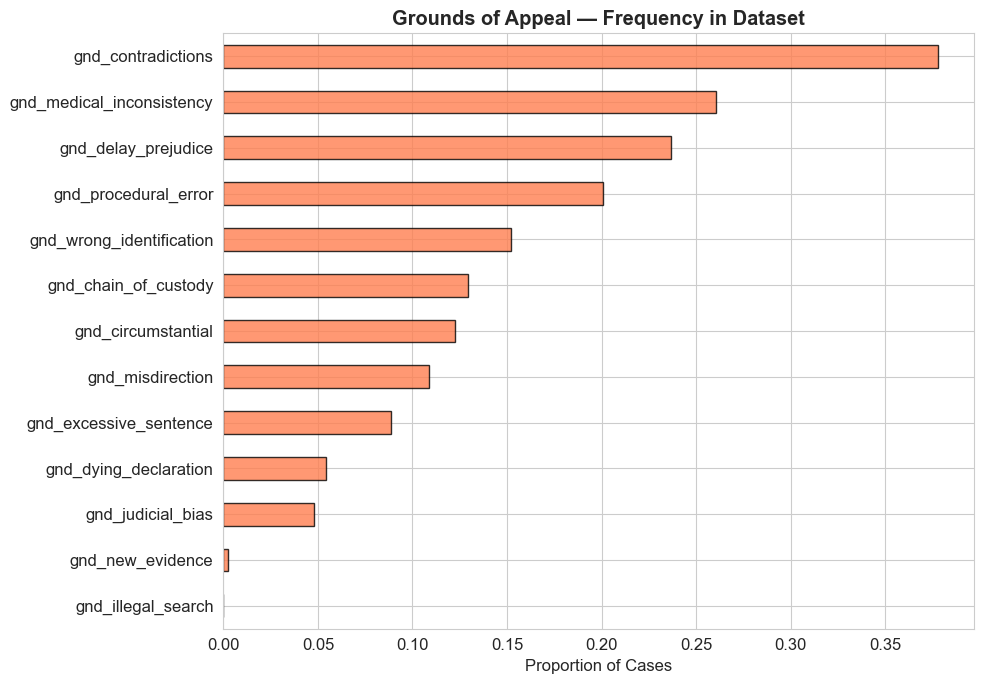

In [19]:
# Visualize legal feature frequency across all cases
ground_cols = [c for c in traditional_features.columns if c.startswith('gnd_')]
ground_freq = traditional_features[ground_cols].mean().sort_values(ascending=True)

plt.figure(figsize=(10, 7))
ground_freq.plot(kind='barh', color='coral', edgecolor='black', alpha=0.8)
plt.xlabel('Proportion of Cases')
plt.title('Grounds of Appeal — Frequency in Dataset', fontweight='bold')
plt.tight_layout()
plt.show()

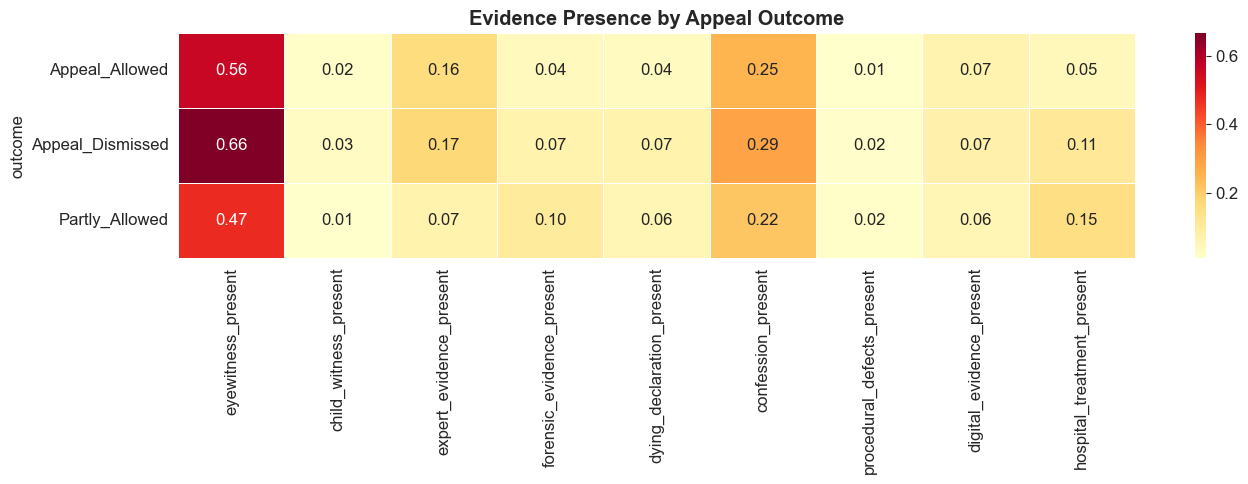

In [20]:
# Evidence presence heatmap by outcome
evidence_cols = [c for c in traditional_features.columns if c.endswith('_present')]

if evidence_cols and 'outcome_clean' in df.columns:
    evidence_by_outcome = traditional_features[evidence_cols].copy()
    evidence_by_outcome['outcome'] = df['outcome_clean'].values
    heatmap_data = evidence_by_outcome.groupby('outcome')[evidence_cols].mean()

    plt.figure(figsize=(14, 5))
    sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5)
    plt.title('Evidence Presence by Appeal Outcome', fontweight='bold')
    plt.tight_layout()
    plt.show()

---
## 🔀 Step 5: Combine Features & Hybrid Feature Selection

In [22]:
# Combine traditional + TF-IDF features
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=[f'tfidf_{f}' for f in tfidf_features],
    index=df.index
)
all_features = pd.concat([traditional_features, tfidf_df], axis=1)

# Try loading BERT embeddings if available
try:
    bert_embeddings = np.load('bert_embeddings_all.npy')
    if len(bert_embeddings) == len(df):
        bert_df = pd.DataFrame(
            bert_embeddings,
            columns=[f'bert_{i}' for i in range(bert_embeddings.shape[1])],
            index=df.index
        )
        all_features = pd.concat([all_features, bert_df], axis=1)
        print(f'✅ BERT features added: {bert_embeddings.shape[1]}')
    else:
        print('⚠️ BERT size mismatch — skipped')
except FileNotFoundError:
    print('ℹ️ BERT embeddings not found — skipped')

print(f'\n📊 Total features: {len(all_features.columns)}')

✅ BERT features added: 768

📊 Total features: 1817


In [23]:
# Prepare target variable
df = df.dropna(subset=['outcome_clean'])
all_features = all_features.loc[df.index]

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(df['outcome_clean'].values)

print(f'🎯 Target classes: {list(label_encoder.classes_)}')
print(f'   Distribution: {np.bincount(y_encoded)}')

🎯 Target classes: ['Appeal_Allowed', 'Appeal_Dismissed', 'Partly_Allowed']
   Distribution: [505 588 158]


In [24]:
def hybrid_feature_selection(X, y):
    """Select features using domain knowledge + statistical tests"""
    all_feats = X.columns.tolist()
    legal_features = [f for f in all_feats if not f.startswith('bert_') and not f.startswith('tfidf_')]
    bert_features = [f for f in all_feats if f.startswith('bert_')]
    tfidf_features = [f for f in all_feats if f.startswith('tfidf_')]

    print(f'Feature inventory:')
    print(f'  Legal: {len(legal_features)} | BERT: {len(bert_features)} | TF-IDF: {len(tfidf_features)}')

    selected = legal_features.copy()  # Keep ALL legal features

    if bert_features:
        k = min(100, len(bert_features))
        sel = SelectKBest(f_classif, k=k).fit(X[bert_features], y)
        selected += [bert_features[i] for i, s in enumerate(sel.get_support()) if s]
        print(f'  Selected {k} BERT features')

    if tfidf_features:
        k = min(50, len(tfidf_features))
        sel = SelectKBest(f_classif, k=k).fit(X[tfidf_features], y)
        selected += [tfidf_features[i] for i, s in enumerate(sel.get_support()) if s]
        print(f'  Selected {k} TF-IDF features')

    return selected

selected_features = hybrid_feature_selection(all_features, y_encoded)
print(f'\n✅ Total selected features: {len(selected_features)}')

Feature inventory:
  Legal: 49 | BERT: 768 | TF-IDF: 1000
  Selected 100 BERT features
  Selected 50 TF-IDF features

✅ Total selected features: 199


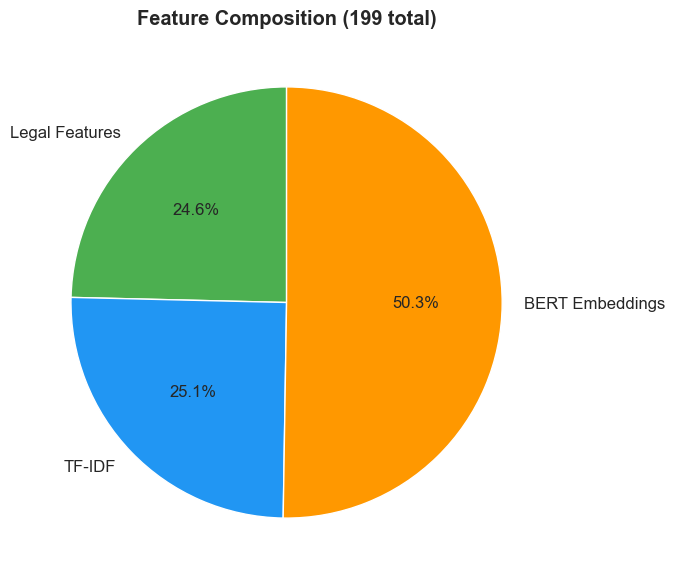

Legal: 49 | BERT: 100 | TF-IDF: 50


In [25]:
# Feature composition pie chart
bert_count   = sum(1 for f in selected_features if f.startswith('bert_'))
tfidf_count  = sum(1 for f in selected_features if f.startswith('tfidf_'))
legal_count  = len(selected_features) - bert_count - tfidf_count

labels  = ['Legal Features', 'TF-IDF', 'BERT Embeddings']
sizes   = [legal_count, tfidf_count, bert_count]
colors  = ['#4CAF50', '#2196F3', '#FF9800']

plt.figure(figsize=(7, 7))
plt.pie([s for s in sizes if s > 0],
        labels=[l for l, s in zip(labels, sizes) if s > 0],
        colors=[c for c, s in zip(colors, sizes) if s > 0],
        autopct='%1.1f%%', startangle=90)
plt.title(f'Feature Composition ({len(selected_features)} total)', fontweight='bold')
plt.show()

print(f'Legal: {legal_count} | BERT: {bert_count} | TF-IDF: {tfidf_count}')

---
## 📅 Step 6: Temporal Train/Test Split

In [26]:
# Sort by year for temporal split
if 'coa_year' in df.columns:
    df_sorted = df.sort_values('coa_year').reset_index(drop=True)
else:
    df_sorted = df.reset_index(drop=True)

all_features_sorted = all_features.loc[df_sorted.index].reset_index(drop=True)
y_sorted = y_encoded[df_sorted.index.values] if hasattr(df_sorted.index, 'values') else y_encoded

split_idx = int(len(df_sorted) * 0.8)

X_train_raw = all_features_sorted.iloc[:split_idx][selected_features]
X_test_raw  = all_features_sorted.iloc[split_idx:][selected_features]
y_train     = y_sorted[:split_idx]
y_test      = y_sorted[split_idx:]

print(f'📅 Train: {len(X_train_raw)} samples | Test: {len(X_test_raw)} samples')

if 'coa_year' in df_sorted.columns:
    print(f'   Train years: {df_sorted["coa_year"].iloc[:split_idx].min()}–{df_sorted["coa_year"].iloc[:split_idx].max()}')
    print(f'   Test years:  {df_sorted["coa_year"].iloc[split_idx:].min()}–{df_sorted["coa_year"].iloc[split_idx:].max()}')

📅 Train: 1000 samples | Test: 251 samples
   Train years: 2004.0–2024.0
   Test years:  2024.0–2025.0


In [27]:
# Scale features
scaler = StandardScaler()

# Handle NaN values before scaling
train_mask = ~X_train_raw.isna().any(axis=1)
test_mask  = ~X_test_raw.isna().any(axis=1)

X_train_clean = X_train_raw[train_mask]
y_train_clean = y_train[train_mask.values]
X_test_clean  = X_test_raw[test_mask]
y_test_clean  = y_test[test_mask.values]

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_clean), columns=selected_features)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test_clean),      columns=selected_features)

print(f'✅ Features scaled')
print(f'   Train: {X_train_scaled.shape} | Test: {X_test_scaled.shape}')

✅ Features scaled
   Train: (801, 199) | Test: (158, 199)


---
## ⚖️ Step 7: Handle Class Imbalance with SMOTE

In [29]:
!pip install --upgrade scikit-learn imbalanced-learn

In [32]:
# smote = SMOTE(random_state=42, k_neighbors=5)
# X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train_clean)

# print(f'Before SMOTE: {np.bincount(y_train_clean)}')
# print(f'After SMOTE:  {np.bincount(y_train_smote)}')

# # Visualize
# fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# before_counts = np.bincount(y_train_clean)
# after_counts  = np.bincount(y_train_smote)

# axes[0].bar(label_encoder.classes_[:len(before_counts)], before_counts,
#             color='#F44336', edgecolor='black', alpha=0.8)
# axes[0].set_title('Before SMOTE', fontweight='bold')
# axes[0].set_ylabel('Count')

# axes[1].bar(label_encoder.classes_[:len(after_counts)], after_counts,
#             color='#4CAF50', edgecolor='black', alpha=0.8)
# axes[1].set_title('After SMOTE', fontweight='bold')
# axes[1].set_ylabel('Count')

# plt.suptitle('Class Distribution Before vs After SMOTE', fontweight='bold', fontsize=14)
# plt.tight_layout()
# plt.show()

# SMOTE alternative - manual oversampling
from sklearn.utils import resample

# Find majority class count
max_count = np.bincount(y_train_clean).max()
X_parts, y_parts = [], []

for class_idx in np.unique(y_train_clean):
    mask = y_train_clean == class_idx
    X_class = X_train_scaled[mask]
    y_class = y_train_clean[mask]
    
    X_resampled, y_resampled = resample(
        X_class, y_class,
        replace=True,
        n_samples=max_count,
        random_state=42
    )
    X_parts.append(X_resampled)
    y_parts.append(y_resampled)

X_train_smote = pd.concat(X_parts).reset_index(drop=True)
y_train_smote = np.concatenate(y_parts)

print(f'Before: {np.bincount(y_train_clean)}')
print(f'After:  {np.bincount(y_train_smote)}')

Before: [333 364 104]
After:  [364 364 364]


---
## 🤖 Step 8: Train & Cross-Validate Models

In [34]:
# # Define models with regularization
# models = {
#     'Logistic Regression': LogisticRegression(
#         C=0.1, penalty='l2', solver='lbfgs',
#         max_iter=1000, random_state=42, class_weight='balanced'
#     ),
#     'Random Forest': RandomForestClassifier(
#         n_estimators=200, max_depth=8, min_samples_split=20,
#         min_samples_leaf=10, max_features='sqrt',
#         random_state=42, class_weight='balanced', n_jobs=-1
#     ),
#     'Gradient Boosting': GradientBoostingClassifier(
#         n_estimators=150, max_depth=4, learning_rate=0.05,
#         subsample=0.8, min_samples_split=20, min_samples_leaf=10, random_state=42
#     ),
#     'SVM': SVC(
#         C=0.5, kernel='rbf', gamma='scale',
#         probability=True, class_weight='balanced', random_state=42
#     )
# }

# cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# cv_results  = []

# for name, model in models.items():
#     print(f'⏳ Training {name}...')
#     cv_scores = cross_val_score(
#         model, X_train_smote, y_train_smote,
#         cv=cv_strategy, scoring='f1_weighted', n_jobs=-1
#     )
#     model.fit(X_train_smote, y_train_smote)
#     train_score = model.score(X_train_scaled, y_train_clean)
#     gap = train_score - cv_scores.mean()

#     status = '✅ Excellent' if gap < 0.05 else ('✓ Good' if gap < 0.10 else '⚠️ Overfitting')
#     print(f'   CV F1: {cv_scores.mean():.4f} ± {cv_scores.std():.4f} | Train: {train_score:.4f} | Gap: {gap:.4f} {status}')

#     cv_results.append({
#         'Model': name,
#         'CV_Mean': cv_scores.mean(),
#         'CV_Std': cv_scores.std(),
#         'Train_Score': train_score,
#         'Gap': gap
#     })

# cv_df = pd.DataFrame(cv_results).sort_values('CV_Mean', ascending=False)
# print('\n📊 Cross-Validation Summary:')
# cv_df


# Define models - n_jobs=1 (no parallel processing to avoid version conflict)
models = {
    'Logistic Regression': LogisticRegression(
        C=0.1, penalty='l2', solver='lbfgs',
        max_iter=1000, random_state=42, class_weight='balanced'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=8, min_samples_split=20,
        min_samples_leaf=10, max_features='sqrt',
        random_state=42, class_weight='balanced',
        n_jobs=1  # ← changed from -1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=150, max_depth=4, learning_rate=0.05,
        subsample=0.8, min_samples_split=20, min_samples_leaf=10, random_state=42
    ),
    'SVM': SVC(
        C=0.5, kernel='rbf', gamma='scale',
        probability=True, class_weight='balanced', random_state=42
    )
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results  = []

for name, model in models.items():
    print(f'⏳ Training {name}...')
    cv_scores = cross_val_score(
        model, X_train_smote, y_train_smote,
        cv=cv_strategy, scoring='f1_weighted',
        n_jobs=1  # ← changed from -1
    )
    model.fit(X_train_smote, y_train_smote)
    train_score = model.score(X_train_scaled, y_train_clean)
    gap = train_score - cv_scores.mean()

    status = '✅ Excellent' if gap < 0.05 else ('✓ Good' if gap < 0.10 else '⚠️ Overfitting')
    print(f'   CV F1: {cv_scores.mean():.4f} ± {cv_scores.std():.4f} | Train: {train_score:.4f} | Gap: {gap:.4f} {status}')

    cv_results.append({
        'Model': name,
        'CV_Mean': cv_scores.mean(),
        'CV_Std': cv_scores.std(),
        'Train_Score': train_score,
        'Gap': gap
    })

cv_df = pd.DataFrame(cv_results).sort_values('CV_Mean', ascending=False)
print('\n📊 Cross-Validation Summary:')
cv_df

⏳ Training Logistic Regression...
   CV F1: 0.9014 ± 0.0262 | Train: 0.8702 | Gap: -0.0313 ✅ Excellent
⏳ Training Random Forest...
   CV F1: 0.8470 ± 0.0209 | Train: 0.8577 | Gap: 0.0107 ✅ Excellent
⏳ Training Gradient Boosting...
   CV F1: 0.9205 ± 0.0232 | Train: 0.9326 | Gap: 0.0121 ✅ Excellent
⏳ Training SVM...
   CV F1: 0.8626 ± 0.0219 | Train: 0.8627 | Gap: 0.0001 ✅ Excellent

📊 Cross-Validation Summary:


,Model,CV_Mean,CV_Std,Train_Score,Gap
2,Gradient Boosting,0.920492,0.023186,0.932584,0.012093
0,Logistic Regression,0.901441,0.026173,0.870162,-0.031279
3,SVM,0.862611,0.021910,0.862672,0.000060
1,Random Forest,0.847013,0.020943,0.857678,0.010665


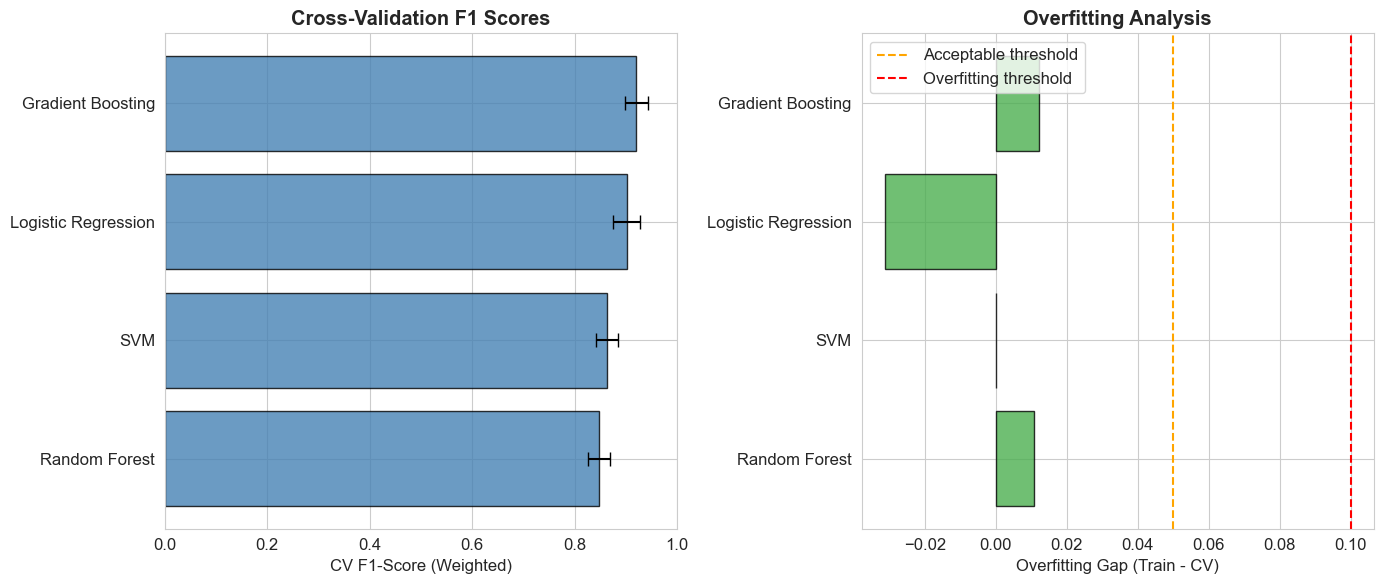

In [35]:
# Visualize CV results
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# CV F1 scores
cv_sorted = cv_df.sort_values('CV_Mean', ascending=True)
axes[0].barh(cv_sorted['Model'], cv_sorted['CV_Mean'],
             xerr=cv_sorted['CV_Std'], capsize=5,
             color='steelblue', alpha=0.8, edgecolor='black')
axes[0].set_xlabel('CV F1-Score (Weighted)')
axes[0].set_title('Cross-Validation F1 Scores', fontweight='bold')
axes[0].set_xlim(0, 1)

# Overfitting gap
axes[1].barh(cv_sorted['Model'], cv_sorted['Gap'],
             color=['#F44336' if g > 0.10 else '#4CAF50' for g in cv_sorted['Gap']],
             alpha=0.8, edgecolor='black')
axes[1].axvline(x=0.05, color='orange', linestyle='--', label='Acceptable threshold')
axes[1].axvline(x=0.10, color='red', linestyle='--', label='Overfitting threshold')
axes[1].set_xlabel('Overfitting Gap (Train - CV)')
axes[1].set_title('Overfitting Analysis', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 🏆 Step 9: Ensemble Model

In [37]:
# # Build ensemble from top 3 models
# top_models = cv_df.head(3)['Model'].tolist()
# print(f'Top 3 models: {top_models}')

# ensemble_estimators = [
#     (name.lower().replace(' ', '_'), models[name])
#     for name in top_models if name in models
# ]

# voting_ensemble = VotingClassifier(
#     estimators=ensemble_estimators,
#     voting='soft'
# )

# calibrated_ensemble = CalibratedClassifierCV(
#     voting_ensemble, cv=3, method='isotonic'
# )

# print('Training calibrated ensemble...')
# calibrated_ensemble.fit(X_train_smote, y_train_smote)

# ensemble_cv_scores = cross_val_score(
#     calibrated_ensemble, X_train_smote, y_train_smote,
#     cv=cv_strategy, scoring='f1_weighted', n_jobs=-1
# )
# ensemble_train = calibrated_ensemble.score(X_train_scaled, y_train_clean)

# print(f'\n🏆 Ensemble Results:')
# print(f'   CV F1: {ensemble_cv_scores.mean():.4f} ± {ensemble_cv_scores.std():.4f}')
# print(f'   Train: {ensemble_train:.4f}')
# print(f'   Gap:   {ensemble_train - ensemble_cv_scores.mean():.4f}')

# Build ensemble from top 3 models
top_models = cv_df.head(3)['Model'].tolist()
print(f'Top 3 models: {top_models}')

ensemble_estimators = [
    (name.lower().replace(' ', '_'), models[name])
    for name in top_models if name in models
]

voting_ensemble = VotingClassifier(
    estimators=ensemble_estimators,
    voting='soft'
)

calibrated_ensemble = CalibratedClassifierCV(
    voting_ensemble, cv=3, method='isotonic'
)

print('Training calibrated ensemble...')
calibrated_ensemble.fit(X_train_smote, y_train_smote)

ensemble_cv_scores = cross_val_score(
    calibrated_ensemble, X_train_smote, y_train_smote,
    cv=cv_strategy, scoring='f1_weighted',
    n_jobs=1  # ← fixed
)
ensemble_train = calibrated_ensemble.score(X_train_scaled, y_train_clean)

print(f'\n🏆 Ensemble Results:')
print(f'   CV F1: {ensemble_cv_scores.mean():.4f} ± {ensemble_cv_scores.std():.4f}')
print(f'   Train: {ensemble_train:.4f}')
print(f'   Gap:   {ensemble_train - ensemble_cv_scores.mean():.4f}')

Top 3 models: ['Gradient Boosting', 'Logistic Regression', 'SVM']
Training calibrated ensemble...

🏆 Ensemble Results:
   CV F1: 0.9179 ± 0.0192
   Train: 0.9039
   Gap:   -0.0140


---
## 📈 Step 10: Final Test Evaluation

In [38]:
# Evaluate all models + ensemble on test set
print('=' * 60)
print('FINAL TEST SET EVALUATION')
print('=' * 60)

all_results = {}

for name, model in {**models, 'Ensemble': calibrated_ensemble}.items():
    y_pred = model.predict(X_test_scaled)
    acc    = accuracy_score(y_test_clean, y_pred)
    f1     = f1_score(y_test_clean, y_pred, average='weighted')
    p, r, _, _ = precision_recall_fscore_support(y_test_clean, y_pred, average='weighted')

    all_results[name] = {'Accuracy': acc, 'F1': f1, 'Precision': p, 'Recall': r}
    marker = ' ⭐' if name == 'Ensemble' else ''
    print(f'{name}{marker}: Acc={acc:.4f} | F1={f1:.4f} | P={p:.4f} | R={r:.4f}')

results_df = pd.DataFrame(all_results).T
print()
results_df

FINAL TEST SET EVALUATION
Logistic Regression: Acc=0.6709 | F1=0.6807 | P=0.7018 | R=0.6709
Random Forest: Acc=0.7532 | F1=0.7581 | P=0.7707 | R=0.7532
Gradient Boosting: Acc=0.7722 | F1=0.7729 | P=0.7806 | R=0.7722
SVM: Acc=0.7848 | F1=0.7870 | P=0.7961 | R=0.7848
Ensemble ⭐: Acc=0.7722 | F1=0.7750 | P=0.7804 | R=0.7722



,Accuracy,F1,Precision,Recall
Logistic Regression,0.670886,0.680670,0.701781,0.670886
Random Forest,0.753165,0.758117,0.770713,0.753165
Gradient Boosting,0.772152,0.772943,0.780551,0.772152
SVM,0.784810,0.787025,0.796101,0.784810
Ensemble,0.772152,0.774950,0.780446,0.772152


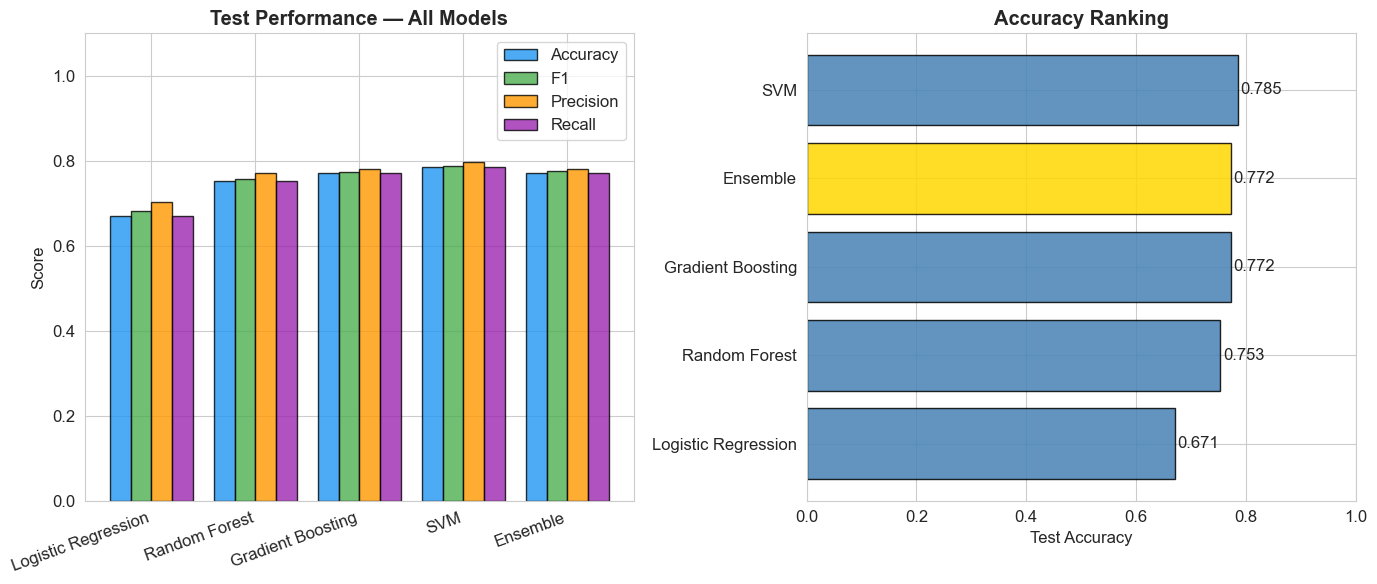

In [39]:
# Visualize test performance comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

metrics = ['Accuracy', 'F1', 'Precision', 'Recall']
x = np.arange(len(results_df))
width = 0.2
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

for i, metric in enumerate(metrics):
    axes[0].bar(x + i * width, results_df[metric], width,
                label=metric, color=colors[i], alpha=0.8, edgecolor='black')

axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels(results_df.index, rotation=20, ha='right')
axes[0].set_ylim(0, 1.1)
axes[0].set_title('Test Performance — All Models', fontweight='bold')
axes[0].legend()
axes[0].set_ylabel('Score')

# Accuracy ranking
acc_sorted = results_df['Accuracy'].sort_values()
bar_colors = ['gold' if n == 'Ensemble' else 'steelblue' for n in acc_sorted.index]
axes[1].barh(acc_sorted.index, acc_sorted.values,
             color=bar_colors, edgecolor='black', alpha=0.85)
axes[1].set_xlabel('Test Accuracy')
axes[1].set_title('Accuracy Ranking', fontweight='bold')
axes[1].set_xlim(0, 1)
for i, v in enumerate(acc_sorted.values):
    axes[1].text(v + 0.005, i, f'{v:.3f}', va='center')

plt.tight_layout()
plt.show()

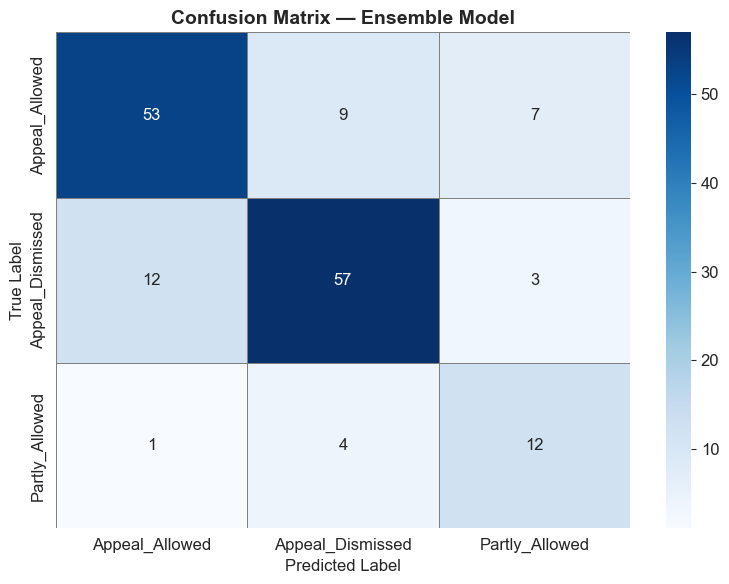

In [40]:
# Confusion matrix for best model (Ensemble)
y_pred_best = calibrated_ensemble.predict(X_test_scaled)
cm = confusion_matrix(y_test_clean, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            linewidths=0.5, linecolor='gray')
plt.title('Confusion Matrix — Ensemble Model', fontweight='bold', fontsize=14)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

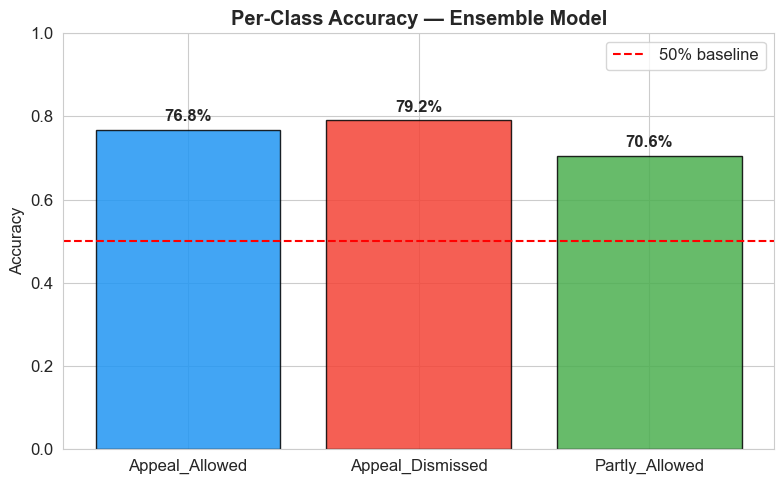

In [41]:
# Per-class accuracy
per_class_acc = {}
for i, class_name in enumerate(label_encoder.classes_):
    if i < len(cm) and cm[i].sum() > 0:
        per_class_acc[class_name] = cm[i, i] / cm[i].sum()
    else:
        per_class_acc[class_name] = 0

plt.figure(figsize=(8, 5))
plt.bar(per_class_acc.keys(), per_class_acc.values(),
        color=['#2196F3', '#F44336', '#4CAF50', '#FF9800'][:len(per_class_acc)],
        edgecolor='black', alpha=0.85)
plt.axhline(y=0.5, color='red', linestyle='--', label='50% baseline')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.title('Per-Class Accuracy — Ensemble Model', fontweight='bold')
plt.legend()
for i, (k, v) in enumerate(per_class_acc.items()):
    plt.text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [42]:
# Full classification report
print('📋 Detailed Classification Report — Ensemble Model')
print('=' * 60)
print(classification_report(y_test_clean, y_pred_best, target_names=label_encoder.classes_))

📋 Detailed Classification Report — Ensemble Model
                  precision    recall  f1-score   support

  Appeal_Allowed       0.80      0.77      0.79        69
Appeal_Dismissed       0.81      0.79      0.80        72
  Partly_Allowed       0.55      0.71      0.62        17

        accuracy                           0.77       158
       macro avg       0.72      0.76      0.73       158
    weighted avg       0.78      0.77      0.77       158



---
## 💾 Step 11: Save Models & Artifacts

In [43]:
# Save all artifacts
with open('improved_ensemble_model.pkl', 'wb') as f:
    pickle.dump(calibrated_ensemble, f)
with open('improved_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open('improved_label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)
with open('improved_tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)
with open('improved_selected_features.pkl', 'wb') as f:
    pickle.dump(selected_features, f)

X_train_scaled.to_csv('X_train_improved.csv', index=False)
X_test_scaled.to_csv('X_test_improved.csv', index=False)
np.save('y_train_improved.npy', y_train_clean)
np.save('y_test_improved.npy', y_test_clean)

test_acc = results_df.loc['Ensemble', 'Accuracy']
test_f1  = results_df.loc['Ensemble', 'F1']

metadata = {
    'model_type': 'Calibrated Voting Ensemble',
    'ensemble_models': top_models,
    'cv_f1_score': float(ensemble_cv_scores.mean()),
    'test_accuracy': float(test_acc),
    'test_f1_score': float(test_f1),
    'n_features': len(selected_features),
    'target_classes': list(label_encoder.classes_),
    'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'smote_applied': True,
    'feature_composition': {'legal': legal_count, 'bert': bert_count, 'tfidf': tfidf_count}
}
with open('improved_model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=4)

print('✅ All artifacts saved!')
print(f'\n🏆 FINAL RESULT: Accuracy = {test_acc:.4f} | F1 = {test_f1:.4f}')

✅ All artifacts saved!

🏆 FINAL RESULT: Accuracy = 0.7722 | F1 = 0.7750


---
## 🔮 Step 12: Predict on New Cases

In [44]:
def predict_appeal_outcome(case_text, brief_facts='', grounds_text='', analysis_text=''):
    """
    Predict appeal outcome for a new case.
    Pass the relevant text fields from the case.
    """
    # Create a single-row dataframe
    new_case = pd.DataFrame([{
        'brief_facts_summary': brief_facts,
        'grounds_of_appeal_raw_text_summary': grounds_text,
        'court_of_appeal_analysis_summary': analysis_text,
    }])

    # Extract features
    new_features = extract_all_legal_features(new_case)
    new_tfidf_text = f'{brief_facts} {grounds_text} {analysis_text}'
    new_tfidf = pd.DataFrame(
        tfidf_vectorizer.transform([new_tfidf_text]).toarray(),
        columns=[f'tfidf_{f}' for f in tfidf_vectorizer.get_feature_names_out()]
    )
    new_all = pd.concat([new_features.reset_index(drop=True),
                         new_tfidf.reset_index(drop=True)], axis=1)

    # Add missing columns with 0
    for col in selected_features:
        if col not in new_all.columns:
            new_all[col] = 0

    new_scaled = pd.DataFrame(
        scaler.transform(new_all[selected_features]),
        columns=selected_features
    )

    proba     = calibrated_ensemble.predict_proba(new_scaled)[0]
    pred_idx  = np.argmax(proba)
    pred_label = label_encoder.classes_[pred_idx]

    print(f'\n🔮 Predicted Outcome: {pred_label}')
    print(f'\nProbabilities:')
    for cls, p in zip(label_encoder.classes_, proba):
        bar = '█' * int(p * 30)
        print(f'  {cls:<15} {p:.3f}  {bar}')

    return pred_label, dict(zip(label_encoder.classes_, proba))

# Example — replace with actual case text
predict_appeal_outcome(
    case_text='',
    brief_facts='The accused was found guilty of murder. The prosecution relied on eyewitness testimony.',
    grounds_text='The conviction is based on contradictory eyewitness testimony. There are inconsistencies in the medical evidence.',
    analysis_text='The court examined the evidence and found the chain of custody was maintained.'
)


🔮 Predicted Outcome: Appeal_Dismissed

Probabilities:
  Appeal_Allowed  0.359  ██████████
  Appeal_Dismissed 0.422  ████████████
  Partly_Allowed  0.219  ██████


('Appeal_Dismissed',
 {'Appeal_Allowed': np.float64(0.3588792094384032),
  'Appeal_Dismissed': np.float64(0.42203475714264155),
  'Partly_Allowed': np.float64(0.21908603341895527)})

---
## 📊 Summary Dashboard

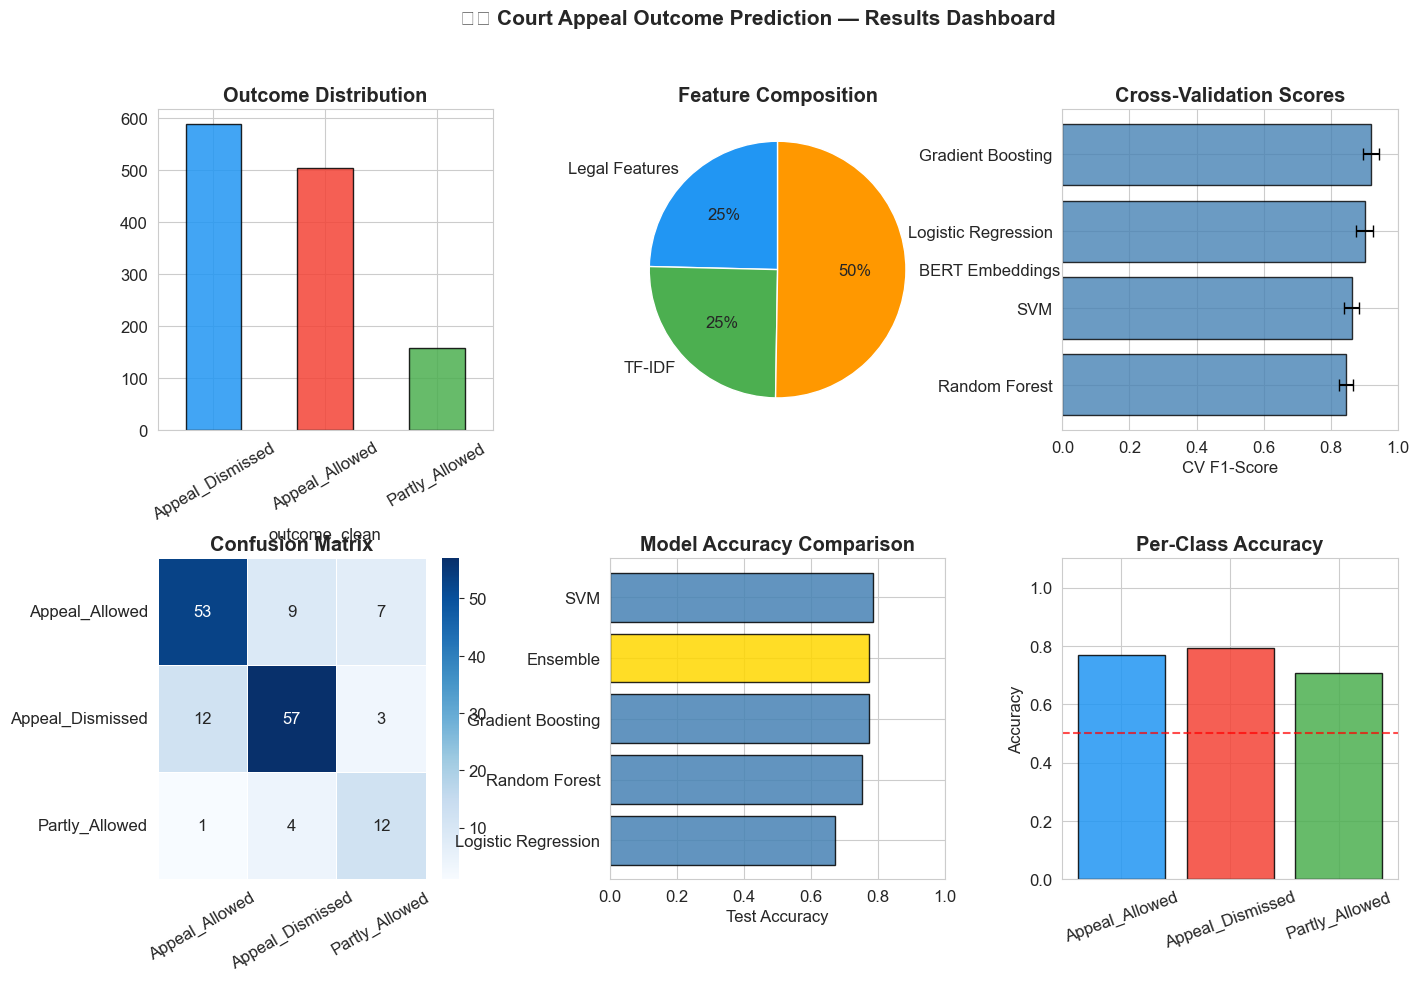

📊 Dashboard saved as results_dashboard.png


In [45]:
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# 1. Outcome distribution
ax1 = fig.add_subplot(gs[0, 0])
outcome_counts.plot(kind='bar', ax=ax1,
    color=['#2196F3','#F44336','#4CAF50','#FF9800'][:len(outcome_counts)],
    edgecolor='black', alpha=0.85)
ax1.set_title('Outcome Distribution', fontweight='bold')
ax1.tick_params(axis='x', rotation=30)

# 2. Feature composition
ax2 = fig.add_subplot(gs[0, 1])
sizes_nz = [(l, s, c) for l, s, c in zip(labels, sizes, colors) if s > 0]
ax2.pie([s for _, s, _ in sizes_nz],
        labels=[l for l, _, _ in sizes_nz],
        colors=[c for _, _, c in sizes_nz],
        autopct='%1.0f%%', startangle=90)
ax2.set_title('Feature Composition', fontweight='bold')

# 3. CV scores
ax3 = fig.add_subplot(gs[0, 2])
cv_s = cv_df.sort_values('CV_Mean', ascending=True)
ax3.barh(cv_s['Model'], cv_s['CV_Mean'], xerr=cv_s['CV_Std'],
         capsize=4, color='steelblue', alpha=0.8, edgecolor='black')
ax3.set_xlabel('CV F1-Score')
ax3.set_title('Cross-Validation Scores', fontweight='bold')
ax3.set_xlim(0, 1)

# 4. Confusion matrix
ax4 = fig.add_subplot(gs[1, 0])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax4,
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_, linewidths=0.5)
ax4.set_title('Confusion Matrix', fontweight='bold')
ax4.tick_params(axis='x', rotation=30)

# 5. Test accuracy comparison
ax5 = fig.add_subplot(gs[1, 1])
acc_s = results_df['Accuracy'].sort_values()
bar_cols = ['gold' if n == 'Ensemble' else 'steelblue' for n in acc_s.index]
ax5.barh(acc_s.index, acc_s.values, color=bar_cols, edgecolor='black', alpha=0.85)
ax5.set_xlabel('Test Accuracy')
ax5.set_title('Model Accuracy Comparison', fontweight='bold')
ax5.set_xlim(0, 1)

# 6. Per-class accuracy
ax6 = fig.add_subplot(gs[1, 2])
ax6.bar(per_class_acc.keys(), per_class_acc.values(),
        color=['#2196F3','#F44336','#4CAF50','#FF9800'][:len(per_class_acc)],
        edgecolor='black', alpha=0.85)
ax6.axhline(y=0.5, color='red', linestyle='--', alpha=0.7)
ax6.set_ylabel('Accuracy')
ax6.set_ylim(0, 1.1)
ax6.set_title('Per-Class Accuracy', fontweight='bold')
ax6.tick_params(axis='x', rotation=20)

plt.suptitle('⚖️ Court Appeal Outcome Prediction — Results Dashboard',
             fontweight='bold', fontsize=15)
plt.savefig('results_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Dashboard saved as results_dashboard.png')